In [1]:
!pip install beautifulsoup4


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Image size: (4181, 2787)
Image mode: RGB


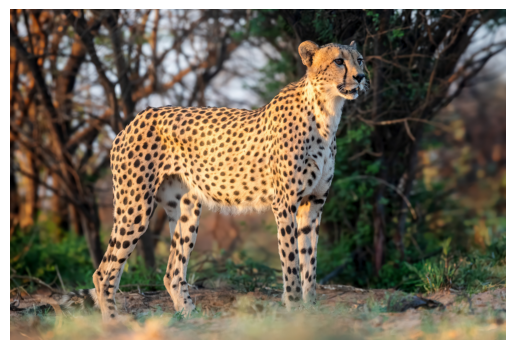

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = r"cheetah.jpg"

img1 = Image.open(image_path)

print("Image size:", img1.size)
print("Image mode:", img1.mode)

plt.imshow(img1)
plt.axis("off")
plt.show()

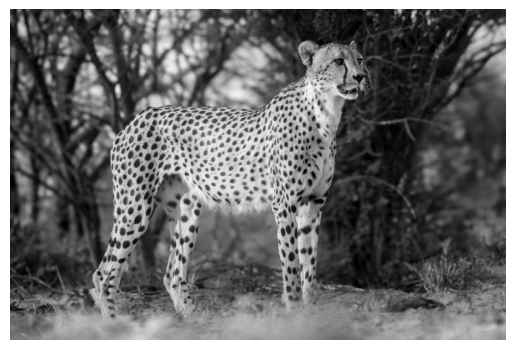

In [3]:
import skimage
img_gray = skimage.color.rgb2gray(img1)
plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.show()

In [4]:
img_gray.shape

(2787, 4181)

In [5]:
from skimage.transform import resize
new_img = resize(img_gray, (300,400))

In [6]:
new_img.shape

(300, 400)

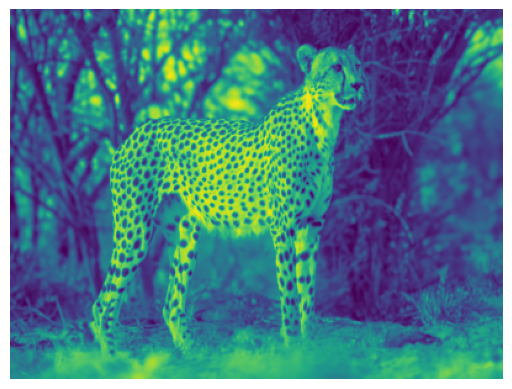

In [7]:
plt.imshow(new_img)
plt.axis("off")
plt.show()

In [4]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation

In [7]:
model = Sequential()
model.add(Conv2D(filters=1, kernel_size=(3,3), input_shape=(300,400,1)))
#model.add(Conv2D(filters=1, kernel_size=(2,2), input_shape=(300,400,1)))
#model.add(Conv2D(filters=1, kernel_size=(1,1), input_shape=(300,400,1)))
model.summary()

C:\Users\lwinm\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 298, 398, 1)         │              10 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.layers[0].get_weights()

[array([[[[-0.15241039]],
 
         [[-0.5590387 ]],
 
         [[-0.02810639]]],
 
 
        [[[ 0.21061409]],
 
         [[ 0.05928481]],
 
         [[ 0.50492036]]],
 
 
        [[[ 0.35671312]],
 
         [[-0.02407628]],
 
         [[-0.5421921 ]]]], dtype=float32),
 array([0.], dtype=float32)]

In [9]:
def convolution(img1, model):
    print("Original Shape:", img1.shape)
    image = img1/255
    img_batch = np.array([image])
    conv_img = model.predict(img_batch)
    conv_img = conv_img.squeeze()
    print("New Shape:", conv_img.shape)
    plt.imshow(conv_img, cmap="gray")
    plt.axis("off")
    plt.show()

Original Shape: (2787, 4181)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
New Shape: (2785, 4179)


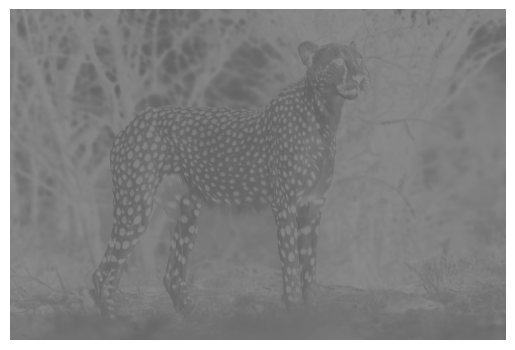

In [10]:
import numpy as np
image = np.array(img1)
image = skimage.color.rgb2gray(image)

convolution(image, model)

In [11]:
model1 = Sequential()
model1.add(Conv2D(filters=1, kernel_size=(3,3), input_shape=(300,400,1)))
model1.add(Activation("relu"))

Original Shape: (2787, 4181)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
New Shape: (2785, 4179)


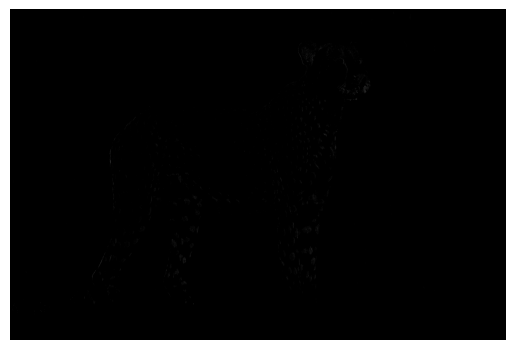

In [12]:
convolution(image, model1)

In [27]:
model2 = Sequential()
model2.add(Conv2D(filters=1, kernel_size=(8,8), input_shape=(300,400,1)))
model2.add(MaxPooling2D(pool_size=(2,2)))

Original Shape: (2787, 4181)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
New Shape: (1390, 2087)


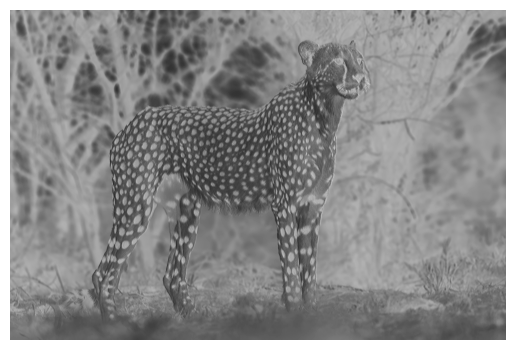

In [28]:
convolution(image, model2)

Original Shape: (2787, 4181)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
New Shape: (1390, 2087)


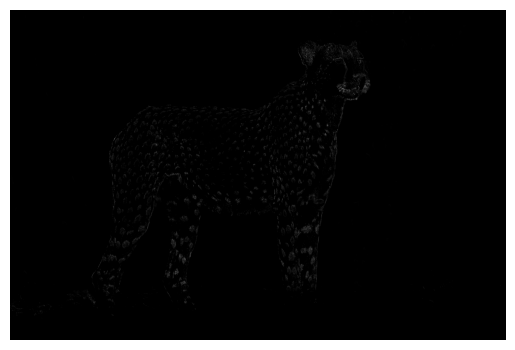

In [19]:
model3 = Sequential()
model3.add(Conv2D(filters=1, kernel_size=(8,8), input_shape=(300,400,1)))
model3.add(Activation("relu"))
model3.add(MaxPooling2D(pool_size=(2,2)))
convolution(image, model3)